# Clonamos el repositorio con los modelos y herramientas

In [1]:
!git clone https://github.com/dannasalazar11/Msc_thesis.git

Cloning into 'Msc_thesis'...
remote: Enumerating objects: 554, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 554 (delta 62), reused 0 (delta 0), pack-reused 427 (from 1)
Receiving objects: 100% (554/554), 52.73 MiB | 42.02 MiB/s, done.
Resolving deltas: 100% (339/339), done.


In [2]:
import sys
sys.path.append('/kaggle/working/Msc_thesis')

from gmrrnet_adhd.utils import get_segmented_data
#from tensorflow.keras.mixed_precision import set_global_policy
#set_global_policy('mixed_float16')


import tensorflow as tf
import numpy as np
import random
import os

# Establecer semilla
seed = 42

# Semillas para módulos principales
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

2025-12-04 14:13:49.870933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764857630.245931      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764857630.353210      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Importar base de datos segmentada (Segmentos de 4 seg con translape del 50%, es decir, de 2 seg)

In [3]:
X, y, sbjs = get_segmented_data()
X.shape, y.shape, len(sbjs)

((8213, 19, 512), (8213, 2), 8213)

# Importamos el modelo y definimos los hiperparámetros

In [4]:
import os

import pickle

with open("/kaggle/input/ieee-tdah-control-database/folds.pkl", "rb") as f:
    folds = pickle.load(f)

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Concatenate, Input, Reshape, Flatten, Dense, Dropout, Activation, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.losses import Loss
from keras_nlp.layers import TransformerEncoder

@tf.keras.utils.register_keras_serializable()
class GaussianKernelLayer(Layer):
    def __init__(self, **kwargs):
        super(GaussianKernelLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # No es necesario agregar sigma como un peso aquí
        super(GaussianKernelLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs ahora será una lista o tupla: [x, sigma]
        x, sigma = inputs  # Asumimos que sigma viene como entrada junto con los datos
        
        # inputs shape: (N, C, T, F)
        N, C, T, F = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        
        # Reshape the input to (N*F, C, T)
        x = tf.transpose(x, perm=(0,3,1,2))  # (N,F,C,T)
        x_reshaped = tf.reshape(x, (N*F, C, T))
        
        # Calculate the pairwise squared Euclidean distance
        squared_differences = tf.expand_dims(x_reshaped, axis=2) - tf.expand_dims(x_reshaped, axis=1)  # (N*F,C,C,T)
        squared_differences = tf.square(squared_differences)  # (N*F,C,C,T)
        pairwise_distances_squared = tf.reduce_sum(squared_differences, axis=-1)  # (N*F,C,C)
        pairwise_distances_squared = tf.reshape(pairwise_distances_squared, (N, F, C, C))  # (N,F,C,C)
        pairwise_distances_squared = tf.transpose(pairwise_distances_squared, perm=(0,2,3,1))  # (N,C,C,F)
        
        # Calculate the Gaussian kernel using the provided sigma
        gaussian_kernel = tf.exp(-pairwise_distances_squared / (2.0 * tf.square(sigma)))
        
        return gaussian_kernel

def renyi_entropy(K, alpha=2):
        """
        input: K tensor, (N,F,C,C)
        output: NxF
        """
        
        C = K.shape[1]
        
        # Normalizamos el kernel antes de calcular la entropía
        
        # Crear una máscara para obtener los elementos diagonales
        diag = tf.expand_dims(tf.linalg.diag_part(K), -1)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(diag, diag, transpose_b=True))
        # Normalización
        
        X = (1/C) * tf.math.divide(K, denominator)
        
        if alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, alpha)), axis=-1)) / (1 - alpha))
                               
def joint_renyi_entropy(K, alpha):
        """
        input: K, (N,F,C,C)
        output: Nx1
        """
        
        C = K.shape[-1]
        product = tf.reduce_prod(K,axis=1) # (N,C,C)
        
        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1,C,C])
        
        argument = product/trace
        argument = tf.expand_dims(argument, axis=1) # es necesario porque renyi_entropy recibe 4 dimensiones (1,C,C)
        joint_entropy = renyi_entropy(argument, alpha=alpha)
                               
        return joint_entropy

@tf.keras.utils.register_keras_serializable()
class RenyiMutualInformation(Loss):
    def __init__(self, C, **kwargs):
        self.C = C
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        F = y_pred.shape[1] - 1
        entropy, joint_entropy = tf.split(y_pred, [F, 1], axis=-1)

        entropy = tf.cast(entropy, tf.float64)
        joint_entropy = tf.cast(joint_entropy, tf.float64)
        log_C = tf.math.log(tf.cast(self.C, tf.float64))

        mutual_information = tf.math.abs(
            tf.expand_dims(tf.reduce_sum(entropy, axis=-1), axis=-1) - joint_entropy
        ) / (F * log_C)

        return mutual_information

    def get_config(self):
        config = super().get_config()
        config.update({"C": self.C})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    
# Normalizamos 
@tf.keras.utils.register_keras_serializable()
class NormalizedBinaryCrossentropy(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_true: N x 2
        y_pred: N x 2 
        """
        batch_size = tf.shape(y_pred)[0]  # batch_size is now an integer tensor
        batch_size_float = tf.cast(batch_size, tf.float32)
        
        cce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        left = tf.tile(tf.expand_dims([1.0, 0.0], axis=0), [batch_size, 1])
        right = tf.tile(tf.expand_dims([0.0, 1.0], axis=0), [batch_size, 1])
        
        cce_left = tf.keras.losses.binary_crossentropy(left, y_pred)
        cce_right = tf.keras.losses.binary_crossentropy(right, y_pred)
        
        cce_norm = tf.divide(cce, (cce_left + cce_right))
        
        return cce_norm

@tf.keras.utils.register_keras_serializable()
class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm = (0,3,1,2))

@tf.keras.utils.register_keras_serializable()        
class RenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=2, **kwargs):
        super(RenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: NxF
        """
        C = tf.shape(K)[-1]

        # Crear una máscara para obtener los elementos diagonales
        diag = tf.linalg.diag_part(K)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(tf.expand_dims(diag, -1), tf.expand_dims(diag, -1), transpose_b=True))
        
        # Normalización
        X = tf.cast((1 / C), tf.float32) * tf.math.divide(K, denominator)

        if self.alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, self.alpha)), axis=-1)) / (1 - self.alpha))


@tf.keras.utils.register_keras_serializable()
class JointRenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha, **kwargs):
        super(JointRenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha
        self.renyi_entropy_layer = RenyiEntropyLayer(alpha)

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: Nx1
        """
        C = tf.shape(K)[-1]
        product = tf.reduce_prod(K, axis=1)  # (N, C, C)

        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1, C, C])

        argument = product / trace
        argument = tf.expand_dims(argument, axis=1)  # Necesario porque renyi_entropy recibe 4 dimensiones (1, C, C)
        
        joint_entropy = self.renyi_entropy_layer(argument)  # Llamada a la capa de entropía de Renyi
        return joint_entropy

In [6]:
import keras
from keras import layers, initializers, activations, ops
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from keras_nlp.layers import TransformerEncoder
from collections import defaultdict


# --- 1. Clase de Atención Inspeccionable (hereda de la original de Keras) ---
class InspectableMultiHeadAttention(layers.MultiHeadAttention):
    """
    Extiende la MultiHeadAttention original de Keras para añadir
    un método de inspección de pesos de proyección.
    """
    def get_projection_weights(self):
        if not self.built:
            raise ValueError("La capa no ha sido construida.")
        
        weights_dict = {
            "query": self._query_dense.kernel.numpy(),
            "key": self._key_dense.kernel.numpy(),
            "value": self._value_dense.kernel.numpy(),
            "output": self._output_dense.kernel.numpy()
        }
        return weights_dict


# --- 3. Nuestra nueva clase de Encoder Inspeccionable ---
class InspectableTransformerEncoder(TransformerEncoder):
    """
    TransformerEncoder que permite inspeccionar pesos de proyección y
    los últimos mapas de atención generados (C×C).
    """
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        key_dim = int(hidden_dim // self.num_heads)

        self._self_attention_layer = InspectableMultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=key_dim,
            value_dim=key_dim,
            dropout=self.dropout,
            name="self_attention_inspectable"
        )

        self._self_attention_layer_norm = layers.LayerNormalization(epsilon=1e-6)
        self._self_attention_dropout = layers.Dropout(rate=self.dropout)
        self._feedforward_intermediate_dense = layers.Dense(self.intermediate_dim, activation=self.activation)
        self._feedforward_output_dense = layers.Dense(hidden_dim)
        self._feedforward_layer_norm = layers.LayerNormalization(epsilon=1e-6)
        self._feedforward_dropout = layers.Dropout(rate=self.dropout)

        # Atributo para almacenar los últimos scores
        self._last_attention_scores = None

        self.built = True

    def call(self, inputs, padding_mask=None, training=False):
        # SELF-ATTENTION
        attention_output, attention_scores = self._self_attention_layer(
            query=inputs,
            key=inputs,
            value=inputs,
            attention_mask=padding_mask,
            training=training,
            return_attention_scores=True
        )

        self._last_attention_scores = attention_scores  # <-- Aquí guardamos los scores

        attention_output = self._self_attention_dropout(attention_output, training=training)
        attention_output = self._self_attention_layer_norm(inputs + attention_output)

        # FEEDFORWARD
        ff_output = self._feedforward_intermediate_dense(attention_output)
        ff_output = self._feedforward_output_dense(ff_output)
        ff_output = self._feedforward_dropout(ff_output, training=training)
        output = self._feedforward_layer_norm(attention_output + ff_output)

        return output

    def get_attention_scores(self):
        """
        Retorna los últimos scores de atención (forma: B × H × C × C).
        """
        if self._last_attention_scores is None:
            raise ValueError("No se han calculado aún los attention scores. Haz un forward pass primero.")
        return self._last_attention_scores

    def get_attention_weights(self):
        """
        Retorna los pesos W_Q, W_K, W_V y W_O de la capa de atención.
        """
        if not self.built:
            raise ValueError("La capa Encoder no ha sido construida.")
        return self._self_attention_layer.get_projection_weights()

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Concatenate, Layer


# 🔹 Capa personalizada que combina kernels y expone pesos convexos
class ConvexCombinationLayer(Layer):
    def __init__(self, num_kernels, **kwargs):
        super().__init__(**kwargs)
        self.num_kernels = num_kernels

    def build(self, input_shape):
        self.alpha = self.add_weight(
            shape=(self.num_kernels,),
            initializer=tf.keras.initializers.Constant(1.0 / self.num_kernels),
            trainable=True,
            name="kernel_weights"
        )

    def call(self, inputs):
        weights = tf.nn.softmax(self.alpha)
        weights_reshaped = tf.reshape(weights, (self.num_kernels, 1, 1, 1))
        combined = tf.add_n([w * k for w, k in zip(tf.unstack(weights_reshaped), inputs)])
        # Devuelve ambos: la mezcla combinada y los pesos (broadcast para mantener shape simbólica)
        weights_broadcast = tf.reshape(weights, (1, self.num_kernels))
        return combined, weights_broadcast


def inception_block(x, F, num_kernels):
    kernels = []

    for i in range(1, num_kernels + 1):
        name = f"gaussian_layer_{i}"
        sigma = 5 / (2 ** (i - 1))
        branch_k = GaussianKernelLayer(name=name)([x, tf.convert_to_tensor(sigma, dtype=tf.float32)])
        kernels.append(branch_k)

    # Combinación convexa con salida dual (combinación + pesos)
    combined_input, kernel_weights_out = ConvexCombinationLayer(num_kernels, name="convex_combination")(kernels)

    # Convolución final
    inception = Conv2D(F, (3, 3), padding='same', activation='relu', name='conv_after_inception')(combined_input)

    # Concatenar los kernels individuales (para la info mutua)
    concatenated_kernels = Concatenate(axis=-1, name='concatenated_kernels')(kernels)

    return concatenated_kernels, inception, kernel_weights_out

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Concatenate, Input, Reshape, Flatten, Dense, Dropout, Activation, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.losses import Loss
from keras_nlp.layers import TransformerEncoder

@tf.keras.utils.register_keras_serializable()
class GaussianKernelLayer(Layer):
    def __init__(self, **kwargs):
        super(GaussianKernelLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # No es necesario agregar sigma como un peso aquí
        super(GaussianKernelLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs ahora será una lista o tupla: [x, sigma]
        x, sigma = inputs  # Asumimos que sigma viene como entrada junto con los datos
        
        # inputs shape: (N, C, T, F)
        N, C, T, F = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        
        # Reshape the input to (N*F, C, T)
        x = tf.transpose(x, perm=(0,3,1,2))  # (N,F,C,T)
        x_reshaped = tf.reshape(x, (N*F, C, T))
        
        # Calculate the pairwise squared Euclidean distance
        squared_differences = tf.expand_dims(x_reshaped, axis=2) - tf.expand_dims(x_reshaped, axis=1)  # (N*F,C,C,T)
        squared_differences = tf.square(squared_differences)  # (N*F,C,C,T)
        pairwise_distances_squared = tf.reduce_sum(squared_differences, axis=-1)  # (N*F,C,C)
        pairwise_distances_squared = tf.reshape(pairwise_distances_squared, (N, F, C, C))  # (N,F,C,C)
        pairwise_distances_squared = tf.transpose(pairwise_distances_squared, perm=(0,2,3,1))  # (N,C,C,F)
        
        # Calculate the Gaussian kernel using the provided sigma
        gaussian_kernel = tf.exp(-pairwise_distances_squared / (2.0 * tf.square(sigma)))
        
        return gaussian_kernel


def renyi_entropy(K, alpha=2):
        """
        input: K tensor, (N,F,C,C)
        output: NxF
        """
        
        C = K.shape[1]
        
        # Normalizamos el kernel antes de calcular la entropía
        
        # Crear una máscara para obtener los elementos diagonales
        diag = tf.expand_dims(tf.linalg.diag_part(K), -1)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(diag, diag, transpose_b=True))
        # Normalización
        
        X = (1/C) * tf.math.divide(K, denominator)
        
        if alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, alpha)), axis=-1)) / (1 - alpha))
                               
def joint_renyi_entropy(K, alpha):
        """
        input: K, (N,F,C,C)
        output: Nx1
        """
        
        C = K.shape[-1]
        product = tf.reduce_prod(K,axis=1) # (N,C,C)
        
        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1,C,C])
        
        argument = product/trace
        argument = tf.expand_dims(argument, axis=1) # es necesario porque renyi_entropy recibe 4 dimensiones (1,C,C)
        joint_entropy = renyi_entropy(argument, alpha=alpha)
                               
        return joint_entropy

@tf.keras.utils.register_keras_serializable()
class RenyiMutualInformation(Loss):
    def __init__(self, C, **kwargs):
        self.C = C
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        F = y_pred.shape[1] - 1
        entropy, joint_entropy = tf.split(y_pred, [F, 1], axis=-1)

        entropy = tf.cast(entropy, tf.float64)
        joint_entropy = tf.cast(joint_entropy, tf.float64)
        log_C = tf.math.log(tf.cast(self.C, tf.float64))

        mutual_information = tf.math.abs(
            tf.expand_dims(tf.reduce_sum(entropy, axis=-1), axis=-1) - joint_entropy
        ) / (F * log_C)

        return mutual_information

    def get_config(self):
        config = super().get_config()
        config.update({"C": self.C})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    
# Normalizamos 
@tf.keras.utils.register_keras_serializable()
class NormalizedBinaryCrossentropy(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_true: N x 2
        y_pred: N x 2 
        """
        batch_size = tf.shape(y_pred)[0]  # batch_size is now an integer tensor
        batch_size_float = tf.cast(batch_size, tf.float32)
        
        cce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        left = tf.tile(tf.expand_dims([1.0, 0.0], axis=0), [batch_size, 1])
        right = tf.tile(tf.expand_dims([0.0, 1.0], axis=0), [batch_size, 1])
        
        cce_left = tf.keras.losses.binary_crossentropy(left, y_pred)
        cce_right = tf.keras.losses.binary_crossentropy(right, y_pred)
        
        cce_norm = tf.divide(cce, (cce_left + cce_right))
        
        return cce_norm

@tf.keras.utils.register_keras_serializable()
class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm = (0,3,1,2))

@tf.keras.utils.register_keras_serializable()        
class RenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=2, **kwargs):
        super(RenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: NxF
        """
        C = tf.shape(K)[-1]

        # Crear una máscara para obtener los elementos diagonales
        diag = tf.linalg.diag_part(K)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(tf.expand_dims(diag, -1), tf.expand_dims(diag, -1), transpose_b=True))
        
        # Normalización
        X = tf.cast((1 / C), tf.float32) * tf.math.divide(K, denominator)

        if self.alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, self.alpha)), axis=-1)) / (1 - self.alpha))


@tf.keras.utils.register_keras_serializable()
class JointRenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha, **kwargs):
        super(JointRenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha
        self.renyi_entropy_layer = RenyiEntropyLayer(alpha)

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: Nx1
        """
        C = tf.shape(K)[-1]
        product = tf.reduce_prod(K, axis=1)  # (N, C, C)

        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1, C, C])

        argument = product / trace
        argument = tf.expand_dims(argument, axis=1)  # Necesario porque renyi_entropy recibe 4 dimensiones (1, C, C)
        
        joint_entropy = self.renyi_entropy_layer(argument)  # Llamada a la capa de entropía de Renyi
        return joint_entropy

In [9]:
def TGARNet(num_kernels=3, nb_classes=2, Chans=19, Samples=512, 
                                       norm_rate=0.25, alpha=2, num_heads=3, intermediate_dim=128):
    
    input1 = Input(shape=(Chans, Samples))

    # 1 Reorganize data for Transformer (Samples, Chans)
    x = Reshape((Samples, Chans))(input1)

    # 2 Normalización antes del Transformer
    x = LayerNormalization()(x)

    # 3 Apply TransformerEncoder
    transformer_encoder = InspectableTransformerEncoder(num_heads=num_heads, intermediate_dim=intermediate_dim, name="transformer_encoder")
    x = transformer_encoder(x)

    # 4 Normalización después del Transformer
    x = LayerNormalization()(x)

    # 5 Restore original shape (Chans, Samples, 1)
    x = Reshape((Chans, Samples, 1))(x)
    
    # 6 Inception with KernelConv
    #concatenated_kernels, inception, kernel_weights = inception_block(x, 5, num_kernels)
    
    # 7 Renyi entropies
    #concatenated_kernels = TransposeLayer()(concatenated_kernels) 
    #layer_entropy = RenyiEntropyLayer(alpha=alpha)(concatenated_kernels)
    #layer_joint_entropy = JointRenyiEntropyLayer(alpha=alpha)(concatenated_kernels)
    #entropies_out = Concatenate(axis=-1, name='concatenated_entropies')([
    #    layer_entropy, layer_joint_entropy
    #])
    
    # 8 Extra convolutional stack
    final_conv = Conv2D(3, kernel_size=3, padding='same', activation='relu', name='Conv2D_2')(x)
    final_conv = BatchNormalization()(final_conv)
    
    final_conv = Conv2D(3, kernel_size=3, padding='same', activation='relu', name='Conv2D_3')(final_conv)
    final_conv = BatchNormalization()(final_conv)
    
    flat = Flatten()(final_conv)
    drop = Dropout(0.3)(flat)  # Aplica aquí
    dense = Dense(nb_classes, name='output', kernel_constraint=max_norm(norm_rate))(drop)
    softmax = Activation('softmax', name='out_activation')(dense)
    
    model = Model(
        inputs=input1,
        outputs={
            'out_activation': softmax       # nombre claro
           # 'entropies_out': entropies_out,   # nombre claro
           # 'kernel_weights_out': kernel_weights  # nueva salida
        }
    )

    
    return model

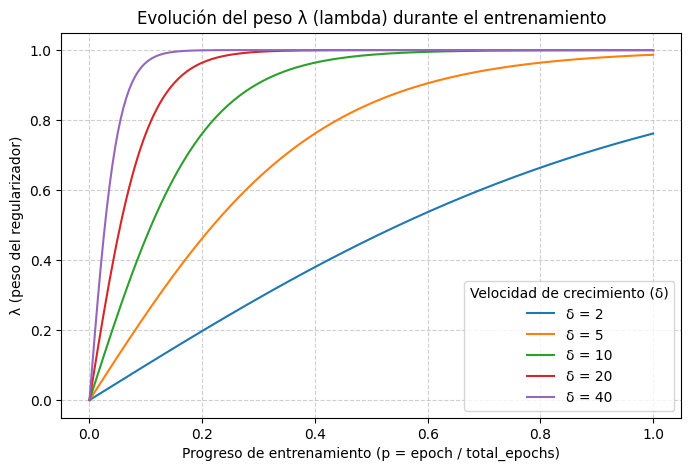

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def get_lambda(p, delta=10):
    """Crecimiento sigmoidal del peso regularizador."""
    return (1 - np.exp(-delta * p)) / (1 + np.exp(-delta * p))

# --- Configuración ---
deltas = [2, 5, 10, 20, 40]  # distintos niveles de crecimiento
p = np.linspace(0, 1, 200)   # progreso normalizado (epoch/total_epochs)

plt.figure(figsize=(8, 5))
for d in deltas:
    λ = get_lambda(p, delta=d)
    plt.plot(p, λ, label=f"δ = {d}")

plt.title("Evolución del peso λ (lambda) durante el entrenamiento")
plt.xlabel("Progreso de entrenamiento (p = epoch / total_epochs)")
plt.ylabel("λ (peso del regularizador)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Velocidad de crecimiento (δ)")
plt.show()

In [11]:
import numpy as np
import os
import scipy.io
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from tensorflow.keras.optimizers import Adam
from copy import deepcopy
from collections import defaultdict
import tensorflow as tf
import random


def train_L24O_cv(model_builder, X, y, sbjs, model_args, compile_args, folds, model_name='', delta=10, seed=42):
    all_fold_metrics = []
    total_histories = []
    models = {}  # <--- aquí se almacenarán todos los modelos entrenados por fold

    for fold, (train_subjects, test_subjects) in enumerate(folds):
        print(f"\n{'-'*60}")
        print(f"Fold {fold+1}/{len(folds)}  |  Test subjects: {test_subjects}")
        print(f"{'-'*60}")

        # --- Índices de entrenamiento y prueba ---
        train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
        test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        sbjs_test = [sbjs[i] for i in test_idx]

        # --- Reiniciar contexto de TensorFlow ---
        tf.keras.backend.clear_session()

        # --- Semillas reproducibles ---
        np.random.seed(seed + fold)
        random.seed(seed + fold)
        tf.random.set_seed(seed + fold)

        # --- Construcción del modelo ---
        model = model_builder(**model_args)
        optimizer = Adam(learning_rate=1e-3)
        compile_args_local = deepcopy(compile_args)
        compile_args_local['optimizer'] = optimizer
        model.compile(**compile_args_local)
        num_kernels = model_args["num_kernels"]

        # --- Callbacks ---
        early_stopping = EarlyStopping(
            monitor='val_loss', patience=25, min_delta=1e-4, restore_best_weights=True, verbose=1
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
        )
        
        #dynamic_schedule = DynamicSchedule(
        #    total_epochs=100, optimizer=Adam(learning_rate=1e-3), delta=delta
        #)

        # --- Entrenamiento ---
        history = model.fit(
            X_train,
            {
                'out_activation': y_train,
                #'entropies_out': np.zeros((len(y_train), 4)),
                #'kernel_weights_out': np.zeros((len(y_train), num_kernels))
            },
            validation_data=(X_test, {
                'out_activation': y_test,
                #'entropies_out': np.zeros((len(y_test), 4)),
                #'kernel_weights_out': np.zeros((len(y_test), num_kernels))
            }),
            epochs=100,
            batch_size=16,
            #callbacks= [
               # dynamic_schedule],
            verbose=0
        )

        total_histories.append(history)

        # --- Pesos convexos ---
        #alpha = model.get_layer("convex_combination").get_weights()[0]
        #print("Pesos convexos aprendidos (softmax):", tf.nn.softmax(alpha).numpy())
        #print("Suma total:", tf.reduce_sum(tf.nn.softmax(alpha)).numpy())

        # --- Predicciones y métricas ---
        preds = model.predict(X_test)
        y_pred_probs = preds['out_activation']
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_test, axis=1)

        fold_metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'kappa': cohen_kappa_score(y_true, y_pred),
            'auc': roc_auc_score(y_true, y_pred_probs[:, 1])
        }
        all_fold_metrics.append(fold_metrics)
        print(f"Fold {fold+1} Metrics: {fold_metrics}")

        # --- Guardar modelo de este fold ---
        models[fold] = model  # ✅ aquí se almacena el modelo

        # --- Accuracy por sujeto ---
        subject_correct = defaultdict(list)
        for yt, yp, sbj in zip(y_true, y_pred, sbjs_test):
            subject_correct[sbj].append(int(yt == yp))

        subject_accuracies = {sbj: np.mean(vals) for sbj, vals in subject_correct.items()}
        print("Accuracy promedio por sujeto:")
        for sbj in test_subjects:
            acc_sbj = subject_accuracies.get(sbj, None)
            if acc_sbj is not None:
                print(f"  {sbj}: {acc_sbj:.4f}")

    # --- Promedio global de métricas ---
    mean_metrics = {}
    for key in all_fold_metrics[0].keys():
        vals = [f[key] for f in all_fold_metrics]
        mean_metrics[f'mean_{key}'] = np.mean(vals)
        mean_metrics[f'std_{key}'] = np.std(vals)

    print("\nIndividual Fold Accuracies:")
    for i, f in enumerate(all_fold_metrics):
        print(f"  Fold {i+1}: {f['accuracy']:.4f}")

    return all_fold_metrics, models, total_histories  # ✅ ahora devuelve todos los modelos

In [12]:
from tensorflow.keras.losses import CategoricalCrossentropy, MeanSquaredError
from tensorflow.keras.utils import get_custom_objects

get_custom_objects().update({
    "RenyiMutualInformation": RenyiMutualInformation
})

model_name = 'TGARNet'
model_args = {
    'num_kernels': 3,
    'nb_classes': 2,
    'Chans': 19,
    'Samples': 512,
    'norm_rate': 0.1,
    'alpha': 2,
    'num_heads': 2,
    'intermediate_dim': 64
}

compile_args = {
    'optimizer': Adam(learning_rate=1e-3),
    'loss': {
        'out_activation': NormalizedBinaryCrossentropy(name="NormalizedBinaryCrossentropy"),
        #'entropies_out': RenyiMutualInformation(C=19.0, name='MutualInfo'),
        #'kernel_weights_out': 'mean_squared_error'
    },
    'loss_weights': {
        'out_activation': 1.0,  # Inicial
        #'entropies_out': 0.5,
        #'kernel_weights_out': 0.0
    },
    'metrics': {'out_activation': ['binary_accuracy', tf.keras.metrics.AUC(name="AUC")]}
    }

I0000 00:00:1764857652.827281      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764857652.827916      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
results = {}

for i in range(10):
    result, models, total_histories = train_L24O_cv(TGARNet, X, y, sbjs, model_args, compile_args, folds, model_name, delta=20)
    results[i]=result


------------------------------------------------------------
Fold 1/5  |  Test subjects: ['v28p', 'v274', 'v1p', 'v231', 'v22p', 'v29p', 'v206', 'v238', 'v31p', 'v35p', 'v177', 'v200', 'v112', 'v113', 'v48p', 'v140', 'v131', 'v125', 'v55p', 'v143', 'v43p', 'v305', 'v134', 'v114']
------------------------------------------------------------


I0000 00:00:1764857663.385015      75 service.cc:148] XLA service 0x796f14006700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764857663.386617      75 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764857663.386643      75 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764857664.248388      75 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764857670.028651      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
Fold 1 Metrics: {'accuracy': 0.6925188743994509, 'recall': 0.6891444635763591, 'precision': 0.6942608773215747, 'kappa': 0.38038961063616916, 'auc': 0.8338714184300754}
Accuracy promedio por sujeto:
  v28p: 0.0000
  v274: 0.9848
  v1p: 1.0000
  v231: 1.0000
  v22p: 1.0000
  v29p: 0.9892
  v206: 0.0779
  v238: 1.0000
  v31p: 1.0000
  v35p: 1.0000
  v177: 1.0000
  v200: 1.0000
  v112: 1.0000
  v113: 1.0000
  v48p: 0.0000
  v140: 0.0152
  v131: 0.1406
  v125: 0.1695
  v55p: 1.0000
  v143: 0.0000
  v43p: 1.0000
  v305: 1.0000
  v134: 0.9608
  v114: 1.0000

------------------------------------------------------------
Fold 2/5  |  Test subjects: ['v18p', 'v39p', 'v234', 'v32p', 'v190', 'v6p', 'v254', 'v204', 'v24p', 'v183', 'v246', 'v219', 'v298', 'v41p', 'v47p', 'v308', 'v52p', 'v300', 'v59p', 'v299', 'v302', 'v51p', 'v109', 'v127']
------------------------------------------------------------
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Fold 2 Metrics: {'a

In [14]:
results

{0: [{'accuracy': 0.6925188743994509,
   'recall': 0.6891444635763591,
   'precision': 0.6942608773215747,
   'kappa': 0.38038961063616916,
   'auc': 0.8338714184300754},
  {'accuracy': 0.7008393285371702,
   'recall': 0.6915770235824101,
   'precision': 0.6971781548504776,
   'kappa': 0.3871494081576754,
   'auc': 0.7890889270083524},
  {'accuracy': 0.7697963800904978,
   'recall': 0.7306946084612664,
   'precision': 0.7873387847360723,
   'kappa': 0.49006746414195823,
   'auc': 0.8262097769593617},
  {'accuracy': 0.6206283343212804,
   'recall': 0.6483372345857501,
   'precision': 0.6655390372653907,
   'kappa': 0.27701775179627275,
   'auc': 0.7418403584562515},
  {'accuracy': 0.8120024494794856,
   'recall': 0.8135985650170368,
   'precision': 0.8168555361091479,
   'kappa': 0.6250387989418267,
   'auc': 0.9141306795154681}],
 1: [{'accuracy': 0.7021276595744681,
   'recall': 0.6975451991481263,
   'precision': 0.7074752233762834,
   'kappa': 0.39826732720376223,
   'auc': 0.792953

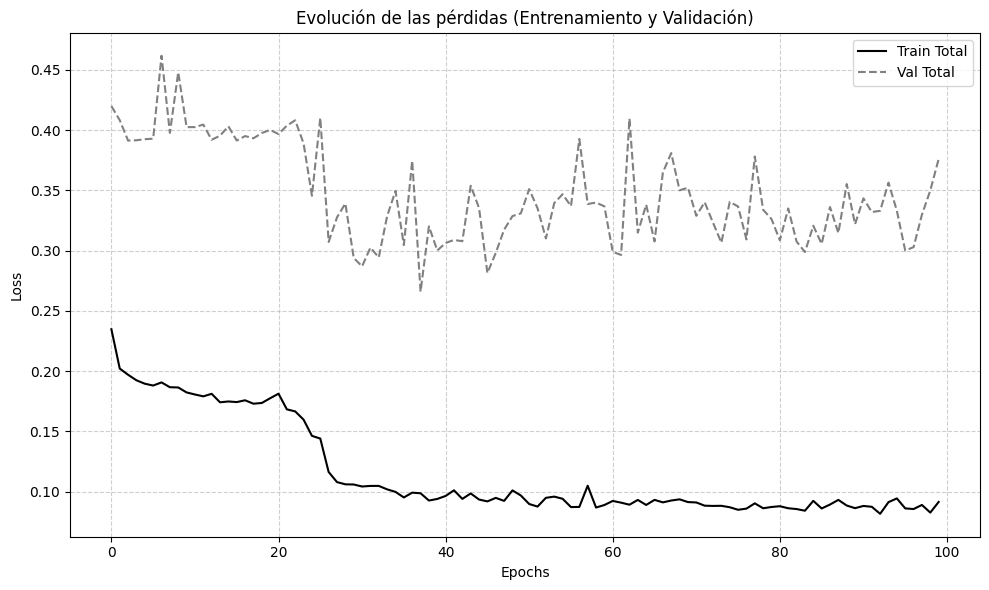

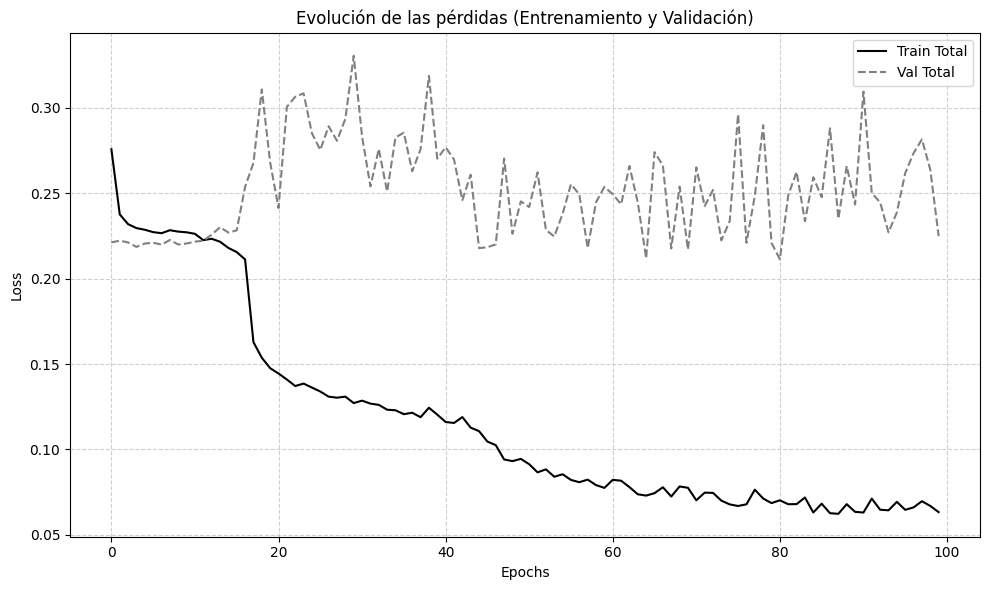

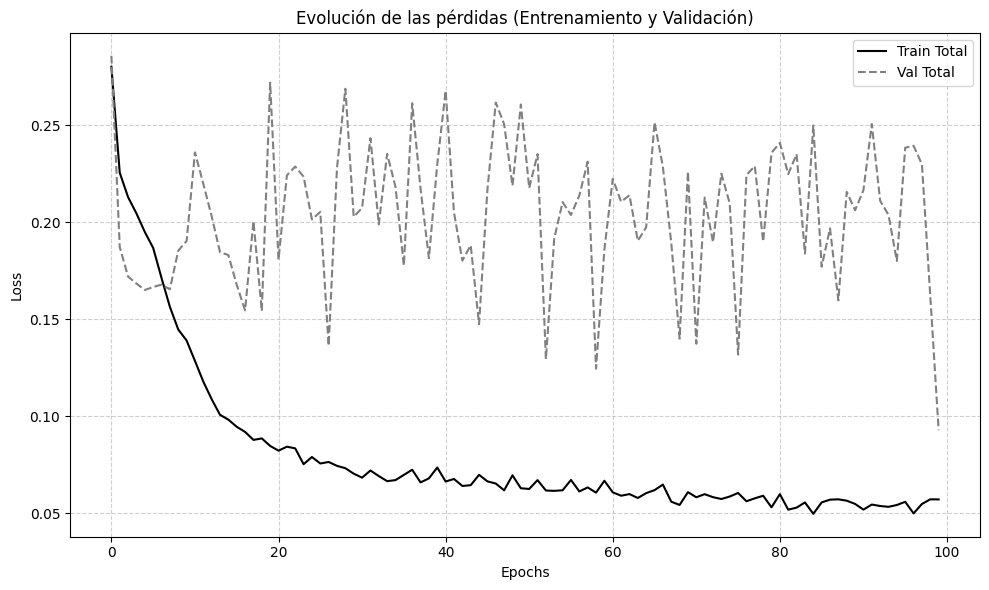

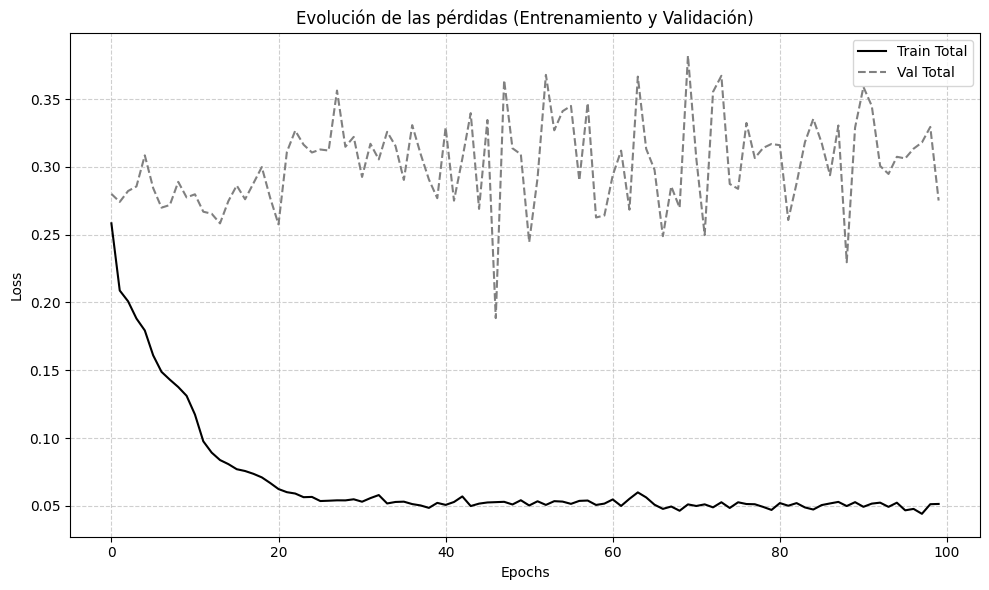

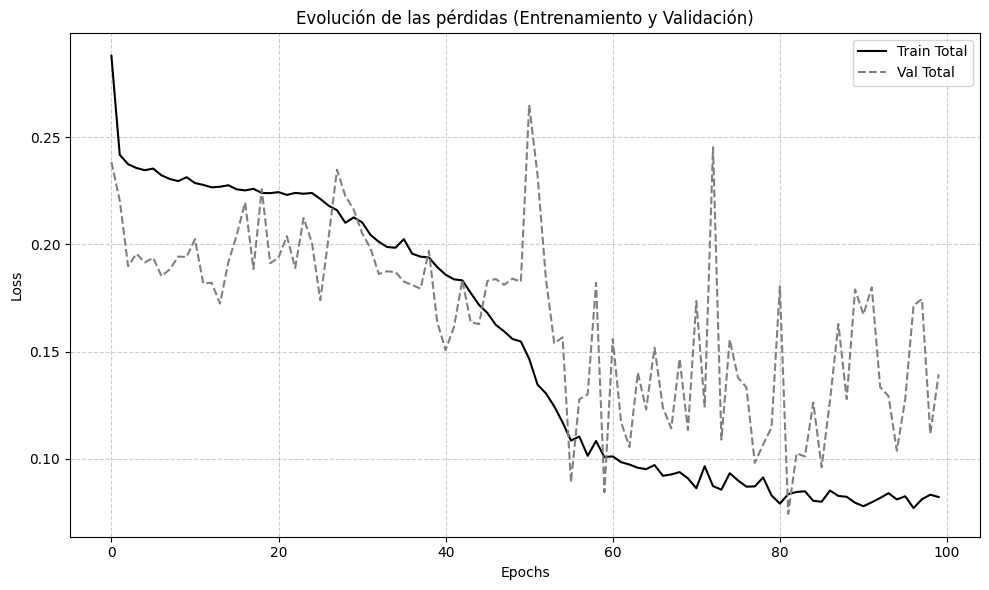

In [15]:
import matplotlib.pyplot as plt

for history in total_histories:
    # Extrae las pérdidas del history
    loss_total = history.history['loss']
    # loss_bce = history.history['out_activation_loss']
    # loss_entropy = history.history['entropies_out_loss']
    
    val_loss_total = history.history['val_loss']
    # val_loss_bce = history.history['val_out_activation_loss']
    # val_loss_entropy = history.history['val_entropies_out_loss']
    
    # --- Gráfico combinado ---
    plt.figure(figsize=(10,6))
    
    # Entrenamiento
    # plt.plot(loss_bce, label='Train BCE', color='tab:blue')
    # plt.plot(loss_entropy, label='Train Renyi MI', color='tab:orange')
    plt.plot(loss_total, label='Train Total', linestyle='-', color='black')
    
    # Validación
    # plt.plot(val_loss_bce, label='Val BCE', color='tab:blue', linestyle=':')
    # plt.plot(val_loss_entropy, label='Val Renyi MI', color='tab:orange', linestyle=':')
    plt.plot(val_loss_total, label='Val Total', linestyle='--', color='gray')
    
    plt.title('Evolución de las pérdidas (Entrenamiento y Validación)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()